In [117]:
%matplotlib inline

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.font_manager as fm
import seaborn as sns
from keplergl import KeplerGl

In [121]:
df = pd.read_csv('/Users/stuber/Desktop/UA/Lab 06/summer-travel-gps-full.csv', encoding='utf-8', index_col='date', parse_dates=True)
rs = pd.read_csv('/Users/stuber/Desktop/UA/Lab 06/summer-travel-gps-dbscan.csv', encoding='utf-8')

In [123]:
df.head()

,lat,lon,city,country
date,,,,
2014-05-14 09:07:00,51.481292,-0.451011,West Drayton,United Kingdom
2014-05-14 09:22:00,51.474005,-0.450999,Hounslow,United Kingdom
2014-05-14 10:51:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:24:00,51.478199,-0.446081,Hounslow,United Kingdom
2014-05-14 11:38:00,51.474146,-0.451562,Hounslow,United Kingdom


In [125]:
rs.head()

,lat,lon,date,city,country
0,51.478199,-0.446081,05/14/2014 10:51,Hounslow,United Kingdom
1,38.781775,-9.137544,05/14/2014 15:11,Lisbon,Portugal
2,38.771939,-9.128911,05/14/2014 15:41,Lisbon,Portugal
3,38.742987,-9.147780,05/14/2014 16:11,Lisbon,Portugal
4,38.693780,-9.206363,05/15/2014 14:19,Lisbon,Portugal


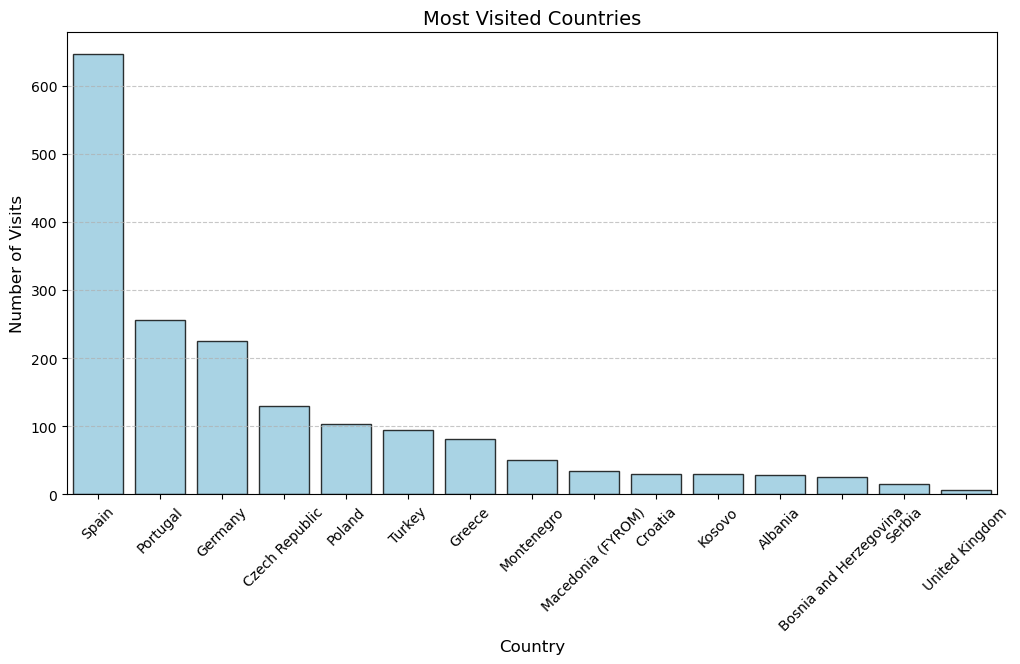

In [127]:
country_counts = df['country'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.index, y=country_counts.values, color='skyblue', edgecolor='black', alpha=0.8)

plt.title("Most Visited Countries", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

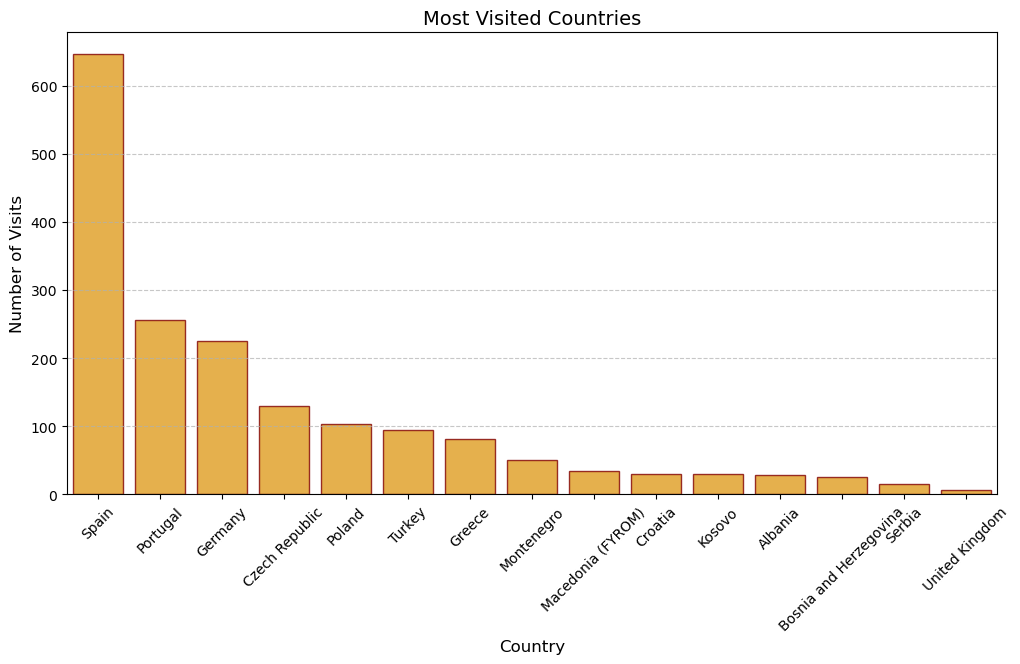

In [129]:
plt.figure(figsize=(12, 6))

sns.barplot(x=country_counts.index, y=country_counts.values, 
            color='orange', edgecolor='maroon', alpha=0.8)

plt.title("Most Visited Countries", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

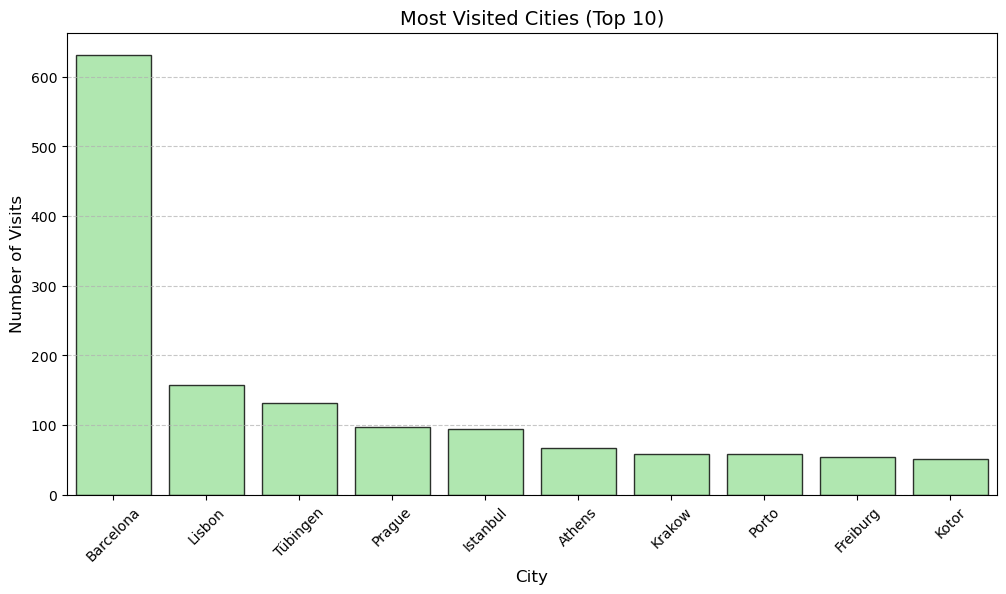

In [131]:
city_counts = df['city'].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(x=city_counts.index[:10], 
            y=city_counts.values[:10],
            color='lightgreen', 
            edgecolor='black', 
            alpha=0.8)

plt.title("Most Visited Cities (Top 10)", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Visits", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

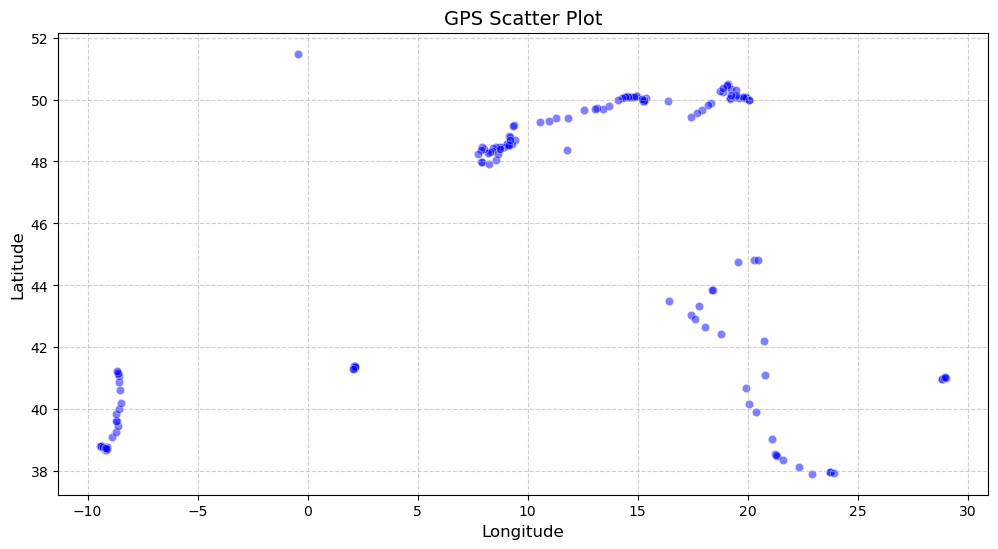

In [133]:
plt.figure(figsize=(12, 6))

sns.scatterplot(x=rs['lon'], y=rs['lat'], alpha=0.5, color='blue')

plt.title("GPS Scatter Plot", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [135]:
countdata = df.groupby(df.index.date).size()
countdata.head()

2014-05-14    36
2014-05-15    61
2014-05-16    57
2014-05-17    64
2014-05-18    50
dtype: int64

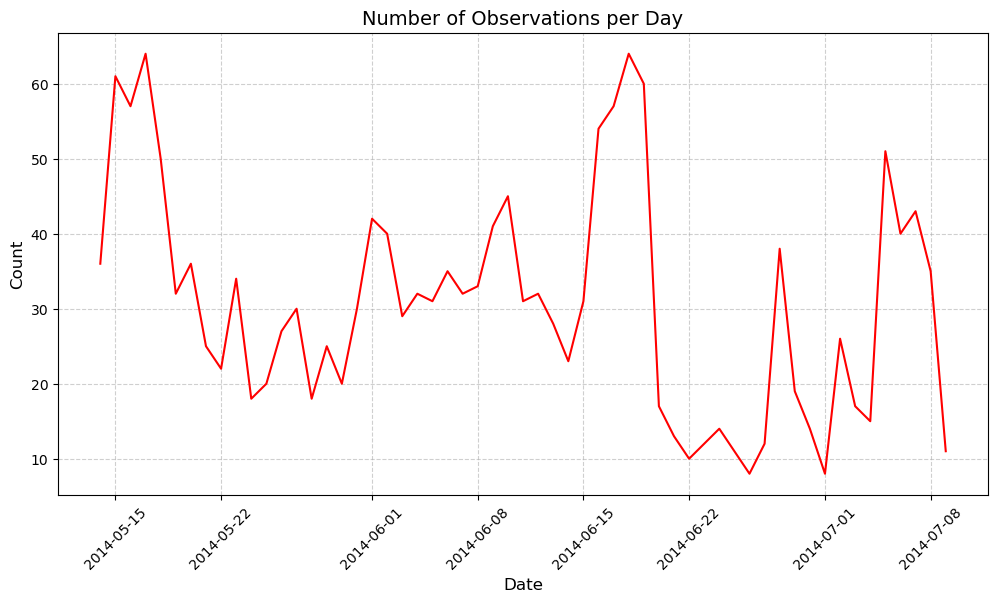

In [137]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=countdata.index, y=countdata.values, color='red')

plt.title("Number of Observations per Day", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.show()

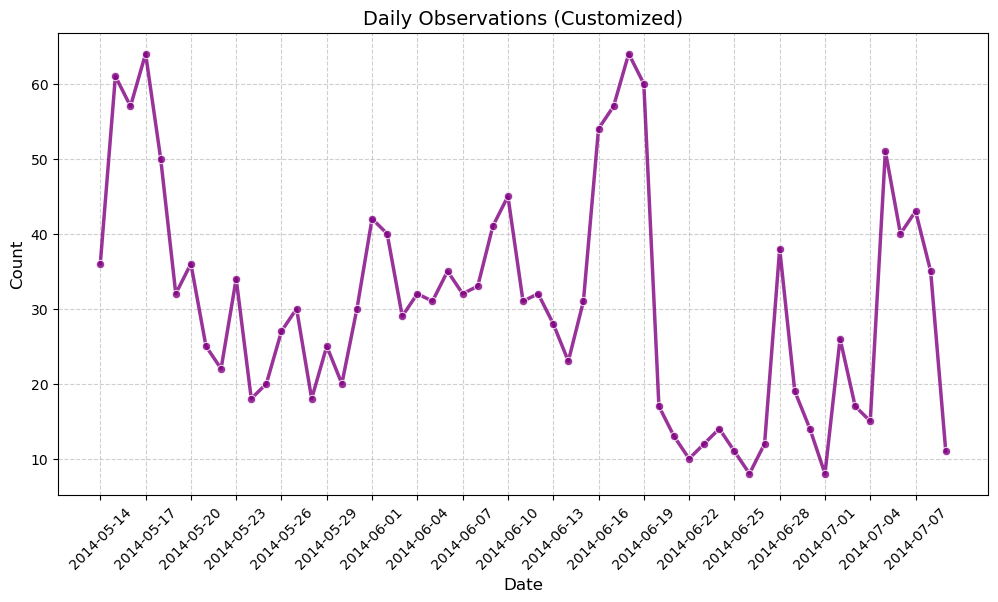

In [139]:
plt.figure(figsize=(12, 6))

sns.lineplot(x=countdata.index, y=countdata.values, 
             color='purple', linewidth=2.5, 
             marker='o', markersize=6, alpha=0.8)

plt.title("Daily Observations (Customized)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(countdata.index[::3], rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [141]:
cities = df['city'].value_counts()
print(cities.count())
cities.head()

113


city
Barcelona    632
Lisbon       158
Tübingen     131
Prague        97
Istanbul      94
Name: count, dtype: int64

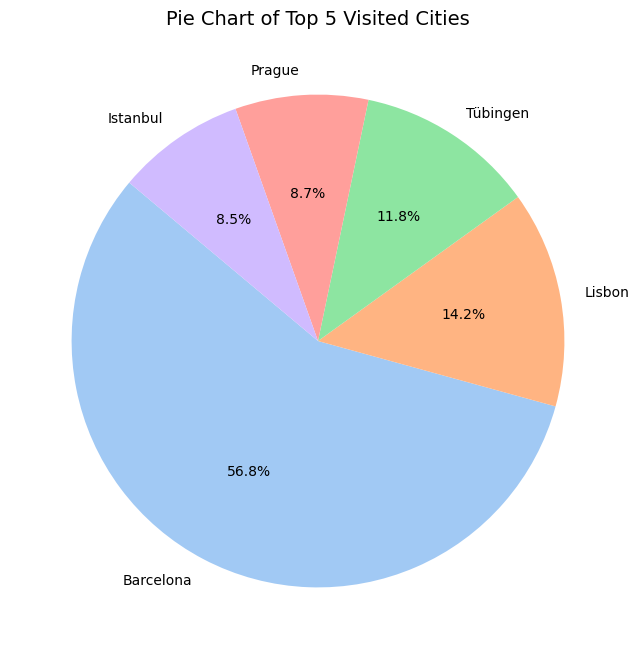

In [143]:
plt.figure(figsize=(8, 8))

top5_cities = cities.nlargest(5)

plt.pie(top5_cities.values, labels=top5_cities.index, 
        autopct='%1.1f%%', 
        startangle=140,
        colors=sns.color_palette("pastel"))

plt.title("Pie Chart of Top 5 Visited Cities", fontsize=14)
plt.show()

In [145]:
df.reset_index(inplace=True)
df['date'] = df['date'].astype(str)

map_1 = KeplerGl(height=500)
map_1.add_data(data=df, name="GPS Data")
map_1

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(data={'GPS Data': {'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20…